### Group Prject - London Bike Rentals

In this project, you will work with the London Bikes dataset, which records daily bike rentals in the city along with key variables such as dates, weather conditions, and seasonality.

The goal is to apply the full data analytics workflow:

- Clean and prepare the dataset.

- Explore the data through visualisation.

- Construct and interpret confidence intervals.

- Build a regression model to explain variation in bike rentals.

- By the end, you will connect statistical concepts with practical Python analysis.

In [26]:
## Import libraries and data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

bikes = pd.read_csv("../Data/london_bikes.csv")
bikes.head()



,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,precipitation,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend
0,2010-07-30T00:00:00Z,6897,2010,Fri,Jul,30,6.0,65.0,10147.0,157.0,22.0,NaN,31.0,17.7,12.3,25.1,False
1,2010-07-31T00:00:00Z,5564,2010,Sat,Jul,30,5.0,70.0,10116.0,184.0,0.0,NaN,47.0,21.1,17.0,23.9,True
2,2010-08-01T00:00:00Z,4303,2010,Sun,Aug,30,7.0,63.0,10132.0,89.0,0.0,NaN,3.0,19.3,14.6,23.4,True
3,2010-08-02T00:00:00Z,6642,2010,Mon,Aug,31,7.0,59.0,10168.0,134.0,0.0,NaN,20.0,19.5,15.6,23.6,False
4,2010-08-03T00:00:00Z,7966,2010,Tue,Aug,31,5.0,66.0,10157.0,169.0,0.0,NaN,39.0,17.9,12.1,20.1,False


**1. Data Cleaning**

Check for missing values across columns. How would you handle them?

Inspect the date column and ensure it is correctly formatted as datetime. Extract useful features (year, month, day, day of week, season).

Convert categorical variables (e.g., season, weather) to appropriate categories in Python.

Ensure numeric columns (e.g., bikes rented, temperature) are in the right format.

In [27]:
## Your code goes here
# Convert date to datetime
bikes["date"] = pd.to_datetime(bikes["date"])

# Create useful date variables
bikes["year"] = bikes["date"].dt.year
bikes["month"] = bikes["date"].dt.month
bikes["month_name"] = bikes["date"].dt.month_name()
bikes["day"] = bikes["date"].dt.day
bikes["day_of_week"] = bikes["date"].dt.day_name()

# Create season
bikes["season"] = np.select(
    [
        bikes["month"].isin([12, 1, 2]),
        bikes["month"].isin([3, 4, 5]),
        bikes["month"].isin([6, 7, 8]),
        bikes["month"].isin([9, 10, 11])
    ],
    ["Winter", "Spring", "Summer", "Autumn"],
    default="Unknown"
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
bikes["season"] = pd.Categorical(
    bikes["season"],
    categories=season_order,
    ordered=True
)

bikes.head()

,date,bikes_hired,year,wday,month,week,cloud_cover,humidity,pressure,radiation,...,snow_depth,sunshine,mean_temp,min_temp,max_temp,weekend,month_name,day,day_of_week,season
0,2010-07-30 00:00:00+00:00,6897,2010,Fri,7,30,6.0,65.0,10147.0,157.0,...,NaN,31.0,17.7,12.3,25.1,False,July,30,Friday,Summer
1,2010-07-31 00:00:00+00:00,5564,2010,Sat,7,30,5.0,70.0,10116.0,184.0,...,NaN,47.0,21.1,17.0,23.9,True,July,31,Saturday,Summer
2,2010-08-01 00:00:00+00:00,4303,2010,Sun,8,30,7.0,63.0,10132.0,89.0,...,NaN,3.0,19.3,14.6,23.4,True,August,1,Sunday,Summer
3,2010-08-02 00:00:00+00:00,6642,2010,Mon,8,31,7.0,59.0,10168.0,134.0,...,NaN,20.0,19.5,15.6,23.6,False,August,2,Monday,Summer
4,2010-08-03 00:00:00+00:00,7966,2010,Tue,8,31,5.0,66.0,10157.0,169.0,...,NaN,39.0,17.9,12.1,20.1,False,August,3,Tuesday,Summer


**2. Exploratory Data Analysis (EDA)**

Plot the distribution of bikes rented.

Explore how rentals vary by season and month.

Investigate the relationship between temperature and bikes rented.

**Deliverables:**

At least 3 clear visualisations with captions.

A short written interpretation of key patterns (seasonality, weather effects, etc.).



Text(0, 0.5, '')

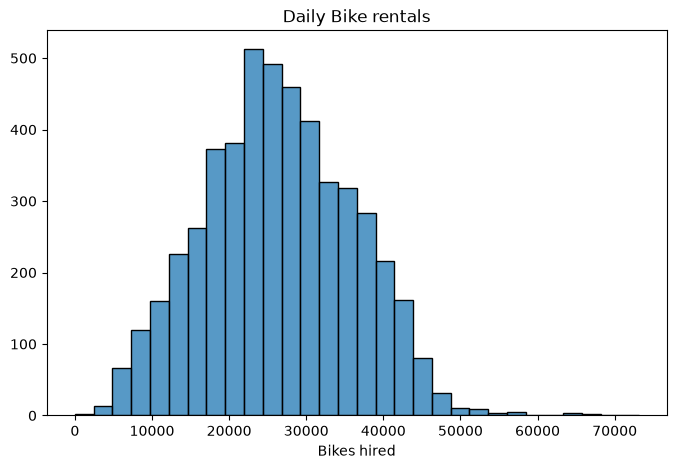

In [18]:
## Distribution of bikes rented
plt.figure(figsize=(8,5))

sns.histplot(data=bikes,
x="bikes_hired",
bins=30
             )
plt.title("Daily Bike rentals")
plt.xlabel("Bikes hired")
plt.ylabel("")

Text(0, 0.5, 'Bikes hired')

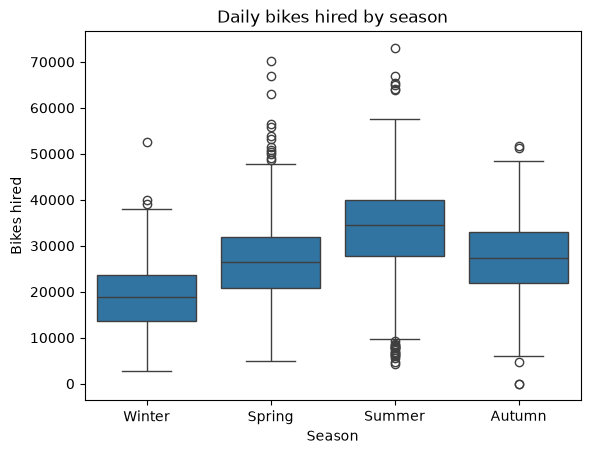

In [19]:
##Rentals vary by season
sns.boxplot(
    data=bikes,
    x="season",
    y = "bikes_hired",
)
plt.title("Daily bikes hired by season")
plt.xlabel("Season")
plt.ylabel("Bikes hired")

Text(0, 0.5, 'Bikes hired')

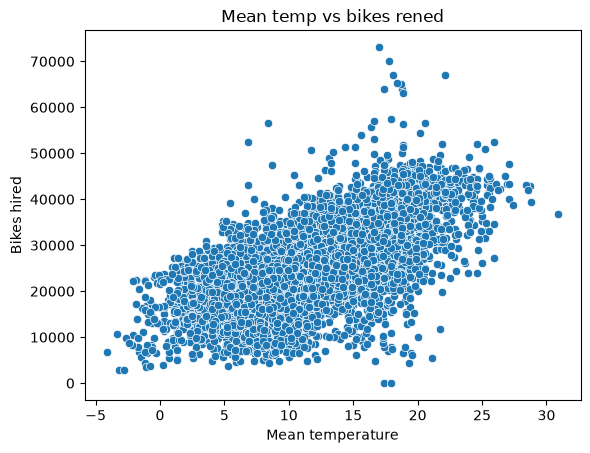

In [20]:
sns.scatterplot(
    data=bikes,
    x="mean_temp",
    y = "bikes_hired",
)
plt.title("Mean temp vs bikes rened")
plt.xlabel("Mean temperature")
plt.ylabel("Bikes hired")

**3. Construct 95% confidence intervals for the mean number of bikes rented per season.**

Repeat the calculation per month.

Interpret the result:

What range of values do you expect the true mean to lie in?

Which seasons/months have higher or lower average demand?

Are there overlaps in the intervals, and what does that mean?

**Deliverables:**

A table or plot showing the mean and confidence intervals.

A short interpretation.

In [29]:
bikes_season = (
    bikes
    .groupby('season')
    .agg(
        mean_bikes = ('bikes_hired','mean'),
        median_bikes= ('bikes_hired','median'),
        std_bikes = ('bikes_hired','std'),
        count = ('bikes_hired','size')
    )
    .reset_index()
)

bikes_season

bikes_season['t_critical'] = bikes_season['count'].apply(lambda n:stats.t.ppf(0.975,df=n-1))
bikes_season['se_hired'] = bikes_season['std_bikes']/np.sqrt( bikes_season['count'])
bikes_season['margin_of_error'] = bikes_season['t_critical'] * bikes_season['se_hired']
bikes_season['low_mean'] = bikes_season['mean_bikes'] - bikes_season['margin_of_error']
bikes_season['high_mean'] = bikes_season['mean_bikes'] + bikes_season['margin_of_error']

bikes_season.sort_values(by='mean_bikes',ascending=False)
bikes_season

,season,mean_bikes,median_bikes,std_bikes,count,t_critical,se_hired,margin_of_error,low_mean,high_mean
0,Winter,18610.162753,18802.0,6625.762758,1235,1.961888,188.539522,369.893476,18240.269277,18980.056229
1,Spring,26609.178930,26469.0,8660.272182,1196,1.961951,250.418236,491.308340,26117.870590,27100.487270
2,Summer,33455.454841,34524.0,9147.748858,1229,1.961898,260.938578,511.934790,32943.520052,33967.389631
3,Autumn,27136.845369,27381.0,7857.506100,1274,1.961829,220.140533,431.878137,26704.967232,27568.723506


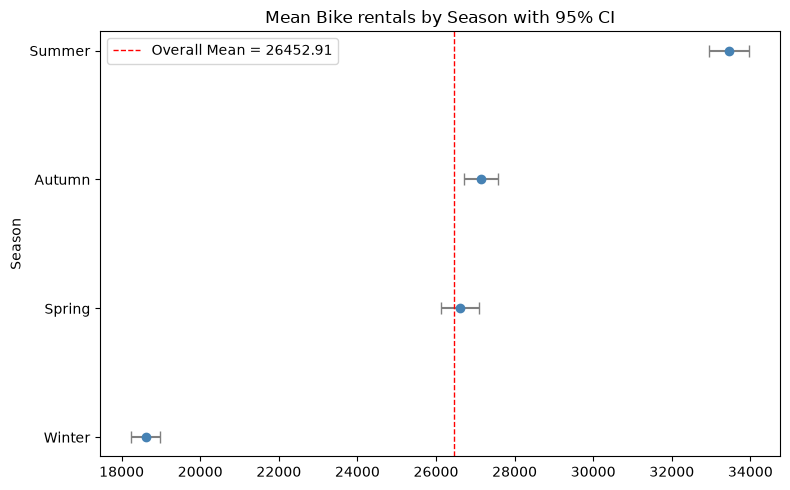

In [32]:
plot_df = bikes_season.sort_values('mean_bikes', ascending=True)

plt.figure(figsize=(8, 5))

# Plot the mean ratings as points with horizontal error bars
plt.errorbar(
    x=plot_df['mean_bikes'],            # mean rating
    y=plot_df['season'],                   # genre labels
    xerr=plot_df['margin_of_error'],      # half-length of CI
    fmt='o',                              # point marker
    color='steelblue',                    # point color
    ecolor='gray',                        # error bar color
    capsize=4,                            # cap size on error bars
    markersize=6                          # marker size
)

# Add a vertical line for overall mean rating
overall_mean = plot_df['mean_bikes'].mean()
plt.axvline(
    overall_mean,
    color='red', linestyle='--', linewidth=1,
    label=f'Overall Mean = {overall_mean:.2f}'
)

# Labels and title\ plt.xlabel('Mean Rating')
plt.ylabel('Season')
plt.title('Mean Bike rentals by Season with 95% CI')
plt.legend()
plt.tight_layout()
plt.show()

**Regression Analysis**

What variables influence the number of bikes rented (y) and how? Build a regression model that best explains the variability in bikes rented.

**Interpret:**

Which predictors are significant?

What do the coefficients mean (in practical terms)?

How much of the variation in bike rentals is explained (R²)?

**Deliverables:**

Regression output table.

A short discussion of which factors matter most for predicting bike rentals.

In [ ]:
### Your code goes here

## Deliverables
A knitted HTML, one person per group to submit